# Demand Forecasting Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

## Datasets

In [2]:
orders = pd.read_csv('cleaned_data.csv')
orders

,Unnamed: 0,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Title,ASIN/ISBN (Product Code),Survey ResponseID,Category
0,1,2018-12-04,7.98,1,NJ,SanDisk Ultra 16GB Class 10 SDHC UHS-I Memory ...,B0143RTB1E,R_01vNIayewjIIKMF,Electronics
1,2,2018-12-22,13.99,1,NJ,Betron BS10 Earphones Wired Headphones in Ear ...,B01MA1MJ6H,R_01vNIayewjIIKMF,Electronics
2,3,2018-12-24,8.99,1,NJ,NaN,B078JZTFN3,R_01vNIayewjIIKMF,NaN
3,4,2018-12-25,10.45,1,NJ,Perfecto Stainless Steel Shaving Bowl. Durable...,B06XWF9HML,R_01vNIayewjIIKMF,Kitchen & Dining
4,5,2018-12-25,10.00,1,NJ,Proraso Shaving Cream for Men,B00837ZOI0,R_01vNIayewjIIKMF,Beauty & Personal Care
...,...,...,...,...,...,...,...,...,...
1850712,1850713,2021-04-01,6.99,1,MA,Tanner's Tasty Paste Vanilla Bling - Anticavit...,B015ZRTHVA,R_zfqnsBzlOAKibzb,"Health, Household & Personal Care"
1850713,1850714,2021-04-14,15.99,1,MA,Sinland Microfiber Cleaning Cloth Dish Cloth K...,B00QGCXPRG,R_zfqnsBzlOAKibzb,"Health, Household & Personal Care"
1850714,1850715,2021-05-22,6.99,4,MA,Tanner's Tasty Paste Vanilla Bling - Anticavit...,B015ZRTHVA,R_zfqnsBzlOAKibzb,"Health, Household & Personal Care"
1850715,1850716,2021-12-01,6.99,4,MA,Tanner's Tasty Paste Vanilla Bling - Anticavit...,B015ZRTHVA,R_zfqnsBzlOAKibzb,"Health, Household & Personal Care"


## Data Cleaning
Handle missing values, remove duplicates, ensure consistent date formats and appropriate data types for all columns

In [3]:
# Data cleaning for orders dataset
# Remove unnecessary columns - Title, Product Code, Survey Response
orders = orders.drop(['Unnamed: 0', 'Title', 'ASIN/ISBN (Product Code)', 'Survey ResponseID'], axis=1)

# Remove null values
orders.isnull().sum()
orders = orders.dropna()

# Convert Order Dateinto datetime
orders['Order Date'] = pd.to_datetime(orders['Order Date'])

orders

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Category
0,2018-12-04,7.98,1,NJ,Electronics
1,2018-12-22,13.99,1,NJ,Electronics
3,2018-12-25,10.45,1,NJ,Kitchen & Dining
4,2018-12-25,10.00,1,NJ,Beauty & Personal Care
5,2019-02-18,10.99,1,NJ,Computer & Accessories
...,...,...,...,...,...
1850711,2021-04-01,20.75,1,MA,Beauty & Personal Care
1850712,2021-04-01,6.99,1,MA,"Health, Household & Personal Care"
1850713,2021-04-14,15.99,1,MA,"Health, Household & Personal Care"
1850714,2021-05-22,6.99,4,MA,"Health, Household & Personal Care"


## Data Preprocessing

In [4]:
# Sort 'Order Date' in ascending order
orders = orders.sort_values(by='Order Date', ascending=True)

# Calculate total sales in a new column
orders['Total Sales'] = orders['Purchase Price Per Unit'] * orders['Quantity']

# Group states by geographic region under a new column `Region`
def regions(state):
    if state in ['NY', 'NJ', 'PA', 'MA', 'CT', 'RI', 'NH', 'VT', 'ME', 'MD', 'DE']:
        return 'Northeast'
    elif state in ['WA', 'OR', 'CA', 'NV', 'UT', 'ID', 'MT', 'WY', 'CO', 'AK', 'HI']:
        return 'West'
    elif state in ['IL', 'OH', 'MI', 'IN', 'WI', 'MN', 'IA', 'MO', 'ND', 'SD', 'NE', 'KS']:
        return 'Midwest'
    elif state in ['TX', 'OK', 'NM', 'AZ']:
        return 'Southwest'
    else:  
        return 'Southeast'

orders['Region'] = orders['Shipping Address State'].apply(regions)

orders

,Order Date,Purchase Price Per Unit,Quantity,Shipping Address State,Category,Total Sales,Region
1660993,2018-01-01,13.49,1,NC,"Clothing, Shoes and Jewellery",13.49,Southeast
1697926,2018-01-01,17.70,1,MO,Books,17.70,Midwest
1697925,2018-01-01,17.99,1,MO,Books,17.99,Midwest
131417,2018-01-01,11.49,1,MI,"Health, Household & Personal Care",11.49,Midwest
131416,2018-01-01,8.74,1,MI,Home,8.74,Midwest
...,...,...,...,...,...,...,...
911617,2023-07-03,8.99,1,NC,Home,8.99,Southeast
911624,2023-07-03,14.99,1,NC,"Health, Household & Personal Care",14.99,Southeast
911623,2023-07-03,27.99,1,NC,Pet Supplies,27.99,Southeast
911625,2023-07-03,2.87,1,NC,Home,2.87,Southeast


## Predicting Top Categories and Total Sales using Random Forest

Aggregate Total Sales by Category 

In [5]:
# Get total sales by Category
category_sales = orders.groupby(['Order Date', 'Region', 'Category']).agg({'Total Sales': 'sum'}).reset_index()

# Remark federal holidays
holidays = pd.to_datetime(['2018-01-01', '2019-01-01', '2020-01-01', '2021-01-01', '2022-01-01', '2023-01-01', # New Year's Day
                            '2018-01-15', '2019-01-21', '2020-01-20', '2021-01-18', '2022-01-17', '2023-01-16', # Martin Luther King Jr's birthday
                            '2018-02-19', '2019-02-18', '2020-02-17', '2021-02-15', '2022-02-21', '2023-02-20', # Washington's birthday
                            '2018-05-28', '2019-05-27', '2020-05-25', '2021-05-31', '2022-05-30', '2023-05-29', # Memorial Day
                            '2018-06-19', '2019-06-19', '2020-06-19', '2021-06-19', '2022-06-19', '2023-06-19', # Juneteenth National Independence Day
                            '2018-07-04', '2019-07-04', '2020-07-04', '2021-07-04', '2022-07-04', '2023-07-04', # Independence Day
                            '2018-09-03', '2019-09-02', '2020-09-07', '2021-09-06', '2022-09-05', '2023-09-04', # Labor Day
                            '2018-10-08', '2019-10-14', '2020-10-12', '2021-10-11', '2022-10-10', '2023-10-09', # Columbus Day
                            '2018-11-11', '2019-11-11', '2020-11-11', '2021-11-11', '2022-11-11', '2023-11-11', # Veterans Day
                            '2018-11-22', '2019-11-28', '2020-11-26', '2021-11-25', '2022-11-24', '2023-11-23', # Thanksgiving Day
                            '2018-12-25', '2019-12-25', '2020-12-25', '2021-12-25', '2022-12-25', '2023-12-25' # Christmas Day
])
category_sales['Holiday'] = np.where(category_sales['Order Date'].isin(holidays), 1, 0)

category_sales['Month'] = category_sales['Order Date'].dt.month
category_sales['Year'] = category_sales['Order Date'].dt.year
category_sales['Day'] = category_sales['Order Date'].dt.dayofweek

category_sales['Weekend'] = np.where(category_sales['Day'].isin([5, 6]), 1, 0)

category_sales

,Order Date,Region,Category,Total Sales,Holiday,Month,Year,Day,Weekend
0,2018-01-01,Midwest,"Arts, Crafts & Sewing",10.95,1,1,2018,0,0
1,2018-01-01,Midwest,Automotive,49.96,1,1,2018,0,0
2,2018-01-01,Midwest,Beauty & Personal Care,116.24,1,1,2018,0,0
3,2018-01-01,Midwest,Books,129.31,1,1,2018,0,0
4,2018-01-01,Midwest,"Clothing, Shoes and Jewellery",182.28,1,1,2018,0,0
...,...,...,...,...,...,...,...,...,...
181730,2023-07-03,Southeast,Electronics,19.89,0,7,2023,0,0
181731,2023-07-03,Southeast,"Health, Household & Personal Care",32.97,0,7,2023,0,0
181732,2023-07-03,Southeast,Home,39.35,0,7,2023,0,0
181733,2023-07-03,Southeast,Pet Supplies,37.48,0,7,2023,0,0


Model Training and Optimisation

Randomised Search CV instead of Grid Search CV to cut down on model training time

In [6]:
# Define features and target
X = category_sales[['Day', 'Month', 'Year', 'Region', 'Weekend', 'Holiday', 'Category']]
y = category_sales['Total Sales']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=10)

# Create a pipeline for Random Forest
pipeline_rf = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', 'passthrough', ['Day', 'Month', 'Year', 'Weekend', 'Holiday']),
            ('cat', OneHotEncoder(drop='first'), ['Region'])])),
    ('model', RandomForestRegressor(random_state=10))
])

# Define hyperparameter grid for Random Forest
param_grid_rf = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5],
    'model__min_samples_leaf': [1, 2, 4]
}

# Initialize RandomizedSearchCV
random_search_rf = RandomizedSearchCV(pipeline_rf, param_distributions=param_grid_rf, 
                                       n_iter=10, cv=5, n_jobs=-1, verbose=2, random_state=10)

# Fit the model
random_search_rf.fit(X_train, y_train)

# Predict and evaluate
rf_predictions1 = random_search_rf.predict(X_test)
rf_mae1 = mean_absolute_error(y_test, rf_predictions1)

print(f'Best Hyperparameters (Random Forest): {random_search_rf.best_params_}')
print(f'Mean Absolute Error of Random Forest: {rf_mae1:.2f}')


Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END model__max_depth=10, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=  52.6s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=100; total time=  55.3s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=100; total time=  55.4s
[CV] END model__max_depth=20, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=  56.1s
[CV] END model__max_depth=20, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=  56.3s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__min_samples_split=5, model__n_estimators=100; total time=  56.3s
[CV] END model__max_depth=20, model__min_samples_leaf=1, model__min_samples_split=2, model__n_estimators=100; total time=  56.7s
[CV] END model__max_depth=None

Random Forest model with optimised hyperparameters

In [8]:
# Save best hyperparameters as variables
best_n_estimators_cats = random_search_rf.best_params_['model__n_estimators']
best_max_depth_cats = random_search_rf.best_params_['model__max_depth']
best_min_samples_split_cats = random_search_rf.best_params_['model__min_samples_split']
best_min_samples_leaf_cats = random_search_rf.best_params_['model__min_samples_leaf']

# Create a pipeline for Random Forest with optimised hyperparameters
pipeline_rf_cats = Pipeline(steps=[
    ('preprocessor', ColumnTransformer(
        transformers=[
            ('num', 'passthrough', ['Day', 'Month', 'Year', 'Weekend', 'Holiday']),
            ('cat', OneHotEncoder(drop='first'), ['Region', 'Category'])])),
    ('model', RandomForestRegressor(
        max_depth=best_max_depth_cats, 
        min_samples_leaf=best_min_samples_leaf_cats, 
        min_samples_split=best_min_samples_split_cats, 
        n_estimators=best_n_estimators_cats,
        random_state=10))
])

# Fit the model again with the optimized hyperparameters
pipeline_rf_cats.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['Day', 'Month', 'Year',
                                                   'Weekend', 'Holiday']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['Region', 'Category'])])),
                ('model',
                 RandomForestRegressor(max_depth=10, n_estimators=200,
                                       random_state=10))])

Run prediction

In [9]:
all_cats = [
    'Arts, Crafts & Sewing', 'Automotive', 'Beauty & Personal Care',
    'Books', 'Clothing, Shoes and Jewellery', 'Computer & Accessories',
    'Electronics', 'Garden & Outdoor', 'Grocery',
    'Health, Household & Personal Care', 'Home',
    'Industrial & Scientific', 'Kitchen & Dining', 'Movies & TV',
    'Office Products', 'Pet Supplies', 'Sports and Outdoors',
    'Tools & Home Improvement', 'Toys and Games', 'Video Games',
    'Luggage & Travel Gear', 'Musical Instruments', 'Software', 'Baby',
    'Gift Cards', 'CDs and Vinyl', 'Amazon Fresh', 'Luxury Beauty',
    'Miscellaneous', 'Watsons', 'Prime Video'
]

In [14]:
def new_data_cats(order_date, region, is_holiday, is_weekend, categories):
    data = {
        'Order Date': [order_date] * len(categories),
        'Region': [region] * len(categories),
        'Category': categories,
        'Holiday': [is_holiday] * len(categories),
        'Weekend': [is_weekend] * len(categories)
    }
    
    input_data = pd.DataFrame(data)

    input_data['Order Date'] = pd.to_datetime(input_data['Order Date'])
    input_data['Day'] = input_data['Order Date'].dt.dayofweek
    input_data['Month'] = input_data['Order Date'].dt.month
    input_data['Year'] = input_data['Order Date'].dt.year

    # Rearrange columns
    input_df = input_data[['Order Date', 'Region', 'Day', 'Month', 'Year', 'Weekend', 'Holiday', 'Category']]

    return input_df

In [15]:
input_df_cats = new_data_cats('2024-01-01', 'Southwest', 1, 1, all_cats)

# Predict sales using the fitted pipeline
rf_pred_cats = pipeline_rf_cats.predict(input_df_cats)

# Create a DataFrame for predictions
results = pd.DataFrame({'Category': all_cats, 'Predicted Sales': rf_pred_cats})

# Round the predicted sales to 2 decimal places
results['Predicted Sales'] = results['Predicted Sales'].round(2)

# Sort the results by predicted sales in descending order
sorted_results = results.sort_values(by='Predicted Sales', ascending=False)

# Print out all predictions in descending order
for index, row in sorted_results.iterrows():
    print(f'Predicted Total Sales for {row["Category"]}: ${row["Predicted Sales"]:.2f}')

# Calculate total sales across all categories
total_sales = sorted_results['Predicted Sales'].sum()
print(f'Predicted Total Sales Across All Categories: ${total_sales:.2f}')

# # Function to get top N categories
# def top_n_categories(order_date, region, holiday, categories, n):
#     # Create input DataFrame using new_data_cats function
#     input_df = new_data_cats(order_date, region, holiday, categories)
    
#     # Predict sales using the fitted pipeline
#     predictions = pipeline_rf_cats.predict(input_df)
    
#     # Create a DataFrame for categories and their predictions
#     results = pd.DataFrame({'Category': categories, 'Predicted Sales': predictions})
    
#     # Round the predicted sales to 2 decimal places
#     results['Predicted Sales'] = results['Predicted Sales'].round(2)
    
#     # Sort the results by predicted sales in descending order
#     top_n_results = results.sort_values(by='Predicted Sales', ascending=False).head(n)
    
#     return top_n_results

# # Example usage for top N categories
# top_n = 5  # Specify how many top categories you want
# top_categories = top_n_categories('2024-01-01', 'Southwest', 1, all_cats, top_n)

# print("\nTop N Categories:")
# print(top_categories)

Predicted Total Sales for Home: $304.69
Predicted Total Sales for Electronics: $301.45
Predicted Total Sales for Health, Household & Personal Care: $224.61
Predicted Total Sales for Pet Supplies: $218.67
Predicted Total Sales for Clothing, Shoes and Jewellery: $216.14
Predicted Total Sales for Computer & Accessories: $186.31
Predicted Total Sales for Toys and Games: $148.88
Predicted Total Sales for Kitchen & Dining: $136.99
Predicted Total Sales for Beauty & Personal Care: $135.88
Predicted Total Sales for Books: $97.26
Predicted Total Sales for Watsons: $93.68
Predicted Total Sales for Miscellaneous: $93.68
Predicted Total Sales for Luggage & Travel Gear: $93.68
Predicted Total Sales for Luxury Beauty: $93.68
Predicted Total Sales for Amazon Fresh: $93.68
Predicted Total Sales for CDs and Vinyl: $93.68
Predicted Total Sales for Gift Cards: $93.68
Predicted Total Sales for Baby: $93.68
Predicted Total Sales for Software: $93.68
Predicted Total Sales for Musical Instruments: $93.68
Pre

## Appendix: Exploratory Data Analysis
Visualise the aggregated sales data

In [12]:
daily_sales = orders.groupby(['Order Date', 'Region']).agg({'Total Sales': 'sum'}).reset_index()

# Remark federal holidays
holidays = pd.to_datetime(['2018-01-01', '2019-01-01', '2020-01-01', '2021-01-01', '2022-01-01', '2023-01-01', # New Year's Day
                            '2018-01-15', '2019-01-21', '2020-01-20', '2021-01-18', '2022-01-17', '2023-01-16', # Martin Luther King Jr's birthday
                            '2018-02-19', '2019-02-18', '2020-02-17', '2021-02-15', '2022-02-21', '2023-02-20', # Washington's birthday
                            '2018-05-28', '2019-05-27', '2020-05-25', '2021-05-31', '2022-05-30', '2023-05-29', # Memorial Day
                            '2018-06-19', '2019-06-19', '2020-06-19', '2021-06-19', '2022-06-19', '2023-06-19', # Juneteenth National Independence Day
                            '2018-07-04', '2019-07-04', '2020-07-04', '2021-07-04', '2022-07-04', '2023-07-04', # Independence Day
                            '2018-09-03', '2019-09-02', '2020-09-07', '2021-09-06', '2022-09-05', '2023-09-04', # Labor Day
                            '2018-10-08', '2019-10-14', '2020-10-12', '2021-10-11', '2022-10-10', '2023-10-09', # Columbus Day
                            '2018-11-11', '2019-11-11', '2020-11-11', '2021-11-11', '2022-11-11', '2023-11-11', # Veterans Day
                            '2018-11-22', '2019-11-28', '2020-11-26', '2021-11-25', '2022-11-24', '2023-11-23', # Thanksgiving Day
                            '2018-12-25', '2019-12-25', '2020-12-25', '2021-12-25', '2022-12-25', '2023-12-25' # Christmas Day
])
daily_sales['Holiday'] = np.where(daily_sales['Order Date'].isin(holidays), 1, 0)

daily_sales['Day'] = daily_sales['Order Date'].dt.dayofweek
daily_sales['Month'] = daily_sales['Order Date'].dt.month
daily_sales['Year'] = daily_sales['Order Date'].dt.year

daily_sales['Weekend'] = np.where(daily_sales['Day'].isin([5, 6]), 1, 0)

daily_sales

,Order Date,Region,Total Sales,Holiday,Day,Month,Year,Weekend
0,2018-01-01,Midwest,3647.52,1,0,1,2018,0
1,2018-01-01,Northeast,2505.95,1,0,1,2018,0
2,2018-01-01,Southeast,3116.26,1,0,1,2018,0
3,2018-01-01,Southwest,942.12,1,0,1,2018,0
4,2018-01-01,West,3547.02,1,0,1,2018,0
...,...,...,...,...,...,...,...,...
9531,2023-05-02,Southeast,44.95,0,1,5,2023,0
9532,2023-06-01,Southeast,75.94,0,3,6,2023,0
9533,2023-06-02,Southeast,14.99,0,4,6,2023,0
9534,2023-07-03,Southeast,129.69,0,0,7,2023,0


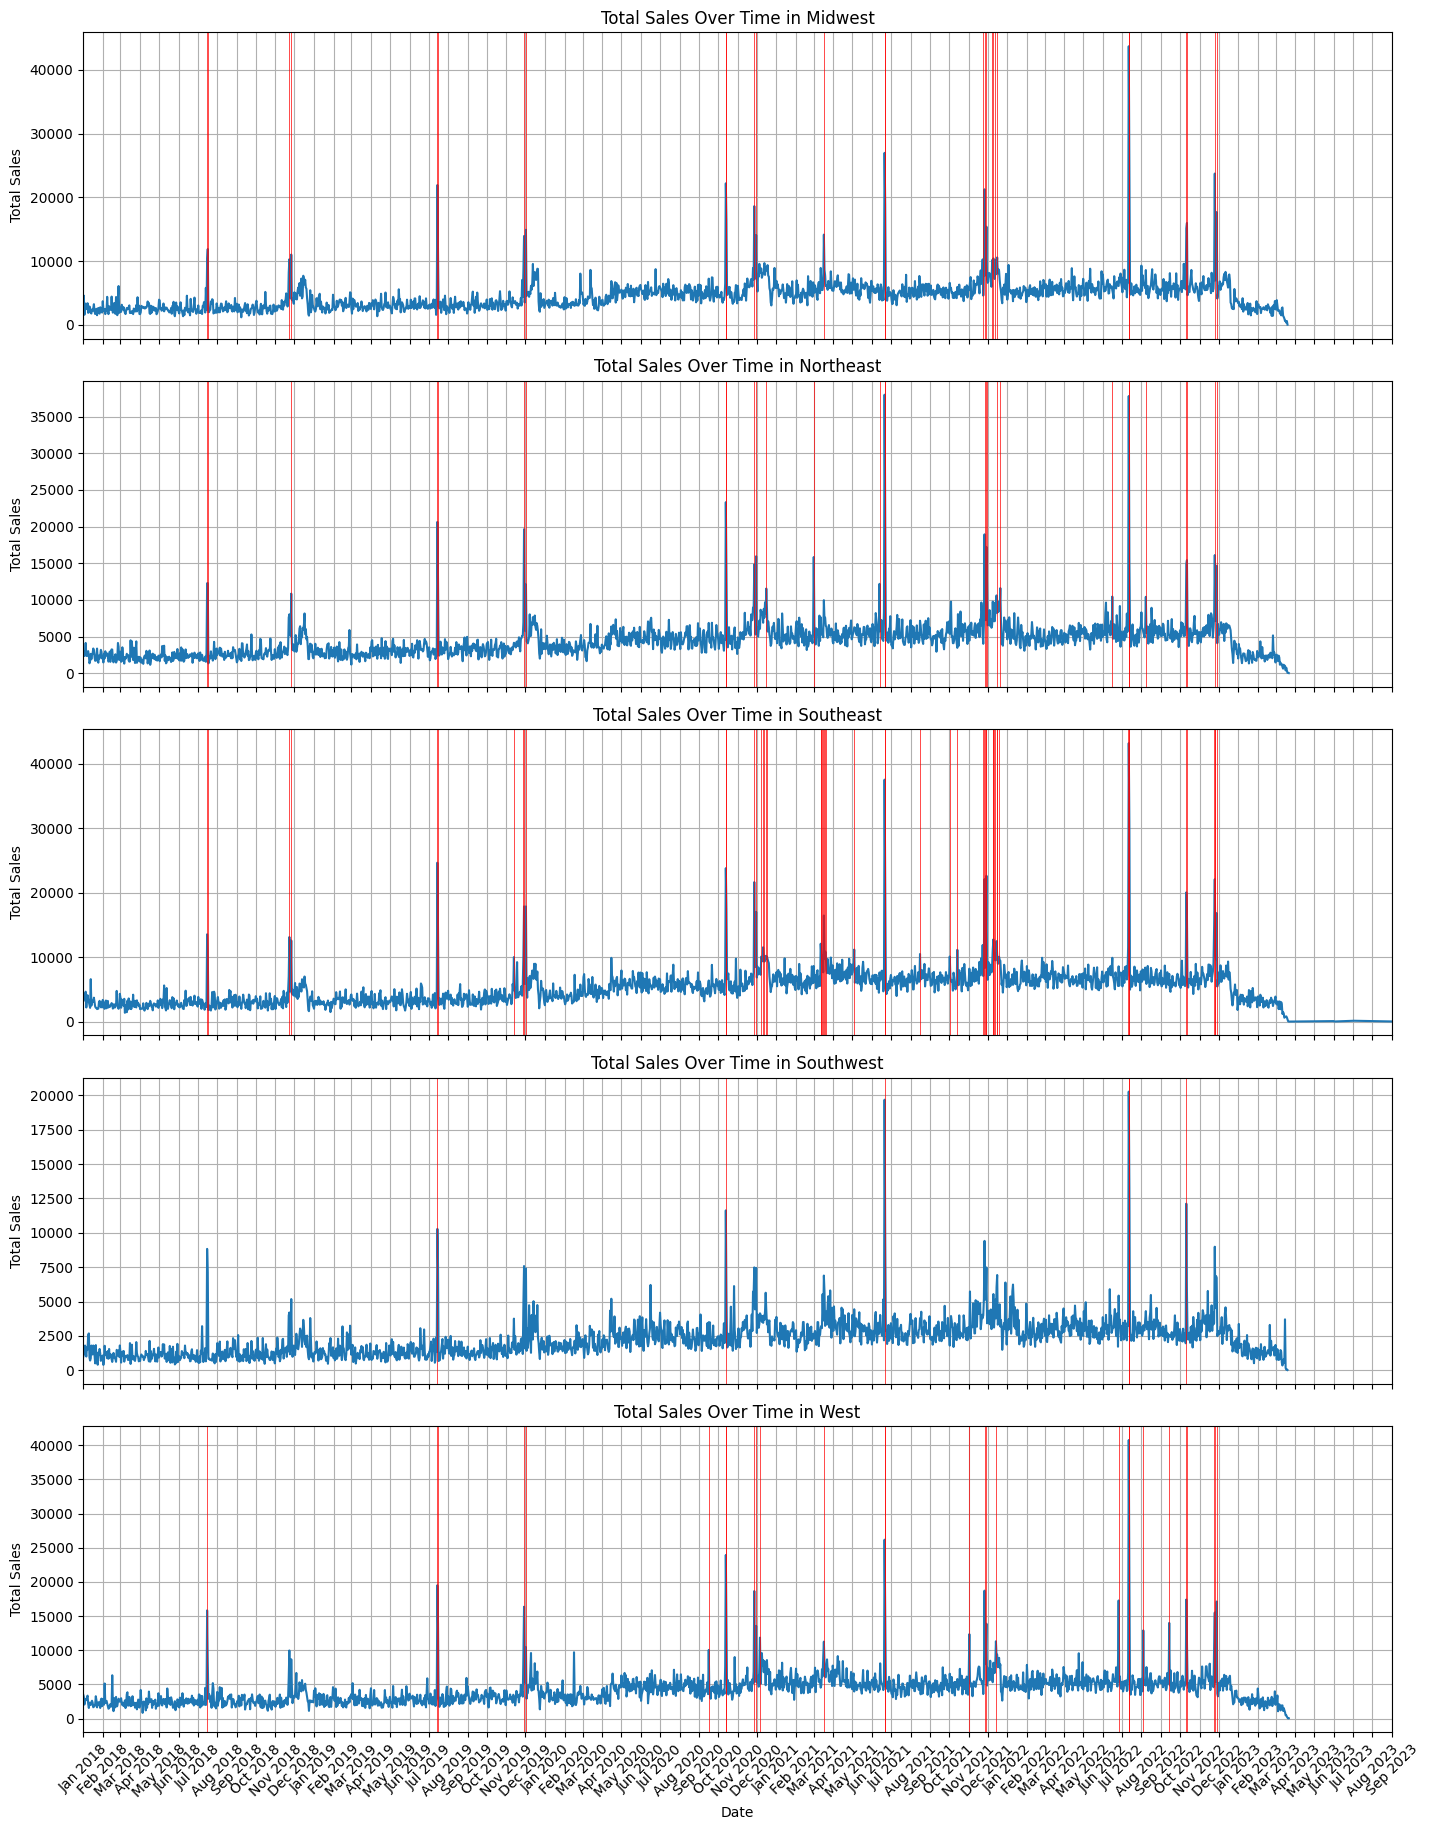

In [13]:
# Create a 5x1 grid of subplots with shared x-axis, increasing the width
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(16, 20), sharex=True)  # Increased width from 12 to 16

# Get the unique regions
regions = daily_sales['Region'].unique()

# Plot total sales for each region in separate subplots
for i, region in enumerate(regions):
    region_sales = daily_sales[daily_sales['Region'] == region]
    axes[i].plot(region_sales['Order Date'], region_sales['Total Sales'])
    axes[i].set_title(f'Total Sales Over Time in {region}')
    axes[i].set_ylabel('Total Sales')
    
    # Draw vertical lines where Total Sales >= 10000
    high_sales_dates = region_sales[region_sales['Total Sales'] >= 10000]['Order Date']
    for date in high_sales_dates:
        axes[i].axvline(x=date, color='red', linestyle='-', linewidth=0.5)  # Solid line

    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid()

    # Set the x-axis limits
    axes[i].set_xlim(pd.Timestamp('2018-01-01'), pd.Timestamp('2023-09-01'))

# Set a common x-axis label
axes[-1].set_xlabel('Date')

# Formatting the x-axis to show each month
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())  # Set major ticks to each month
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))  # Format the ticks as "Month Year"

plt.tight_layout(rect=[0, 0.03, 0.9, 0.95])  # Adjust layout to prevent clipping
plt.show()

From the graphs, it can be seen that a great increase in sales (sales >= 10,000 are marked with a red vertical line) occurs on holidays across all regions and years.